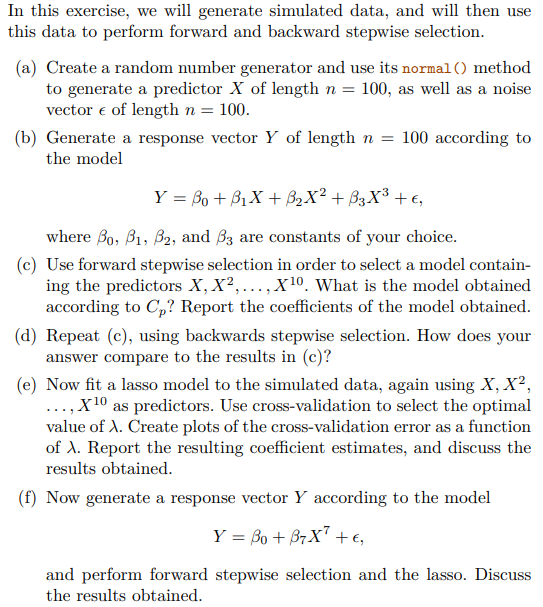

=== Problem 6-8: Forward/Backward Stepwise Selection and Lasso ===

=== Part (a): Generate Predictor and Noise ===
Generated X: n=100, mean=-0.050, std=0.773
Generated ε: n=100, mean=-0.011, std=0.975

=== Part (b): Generate Response Y ===
True model: Y = 2 + -1X + 0.5X² + -0.2X³ + ε
Generated Y: n=100, mean=2.370, std=1.417

=== Creating Polynomial Features ===
Available predictors: ['Y', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10']
Dataset shape: (100, 11)

=== Part (c): Forward Stepwise Selection ===
Performing forward stepwise selection...
Step 1: Added feature 7, Cp = 2.000
Step 2: Added feature 0, Cp = 3.000
Step 3: Added feature 1, Cp = 4.000
Step 4: Added feature 2, Cp = 5.000
Step 5: Added feature 3, Cp = 6.000
Step 6: Added feature 4, Cp = 7.000
Step 7: Added feature 5, Cp = 8.000
Step 8: Added feature 6, Cp = 9.000
Step 9: Added feature 8, Cp = 10.000
Step 10: Added feature 9, Cp = 11.000

Best forward model (min Cp):
Step 1, Cp = 2.000
Features included: ['X8']

C

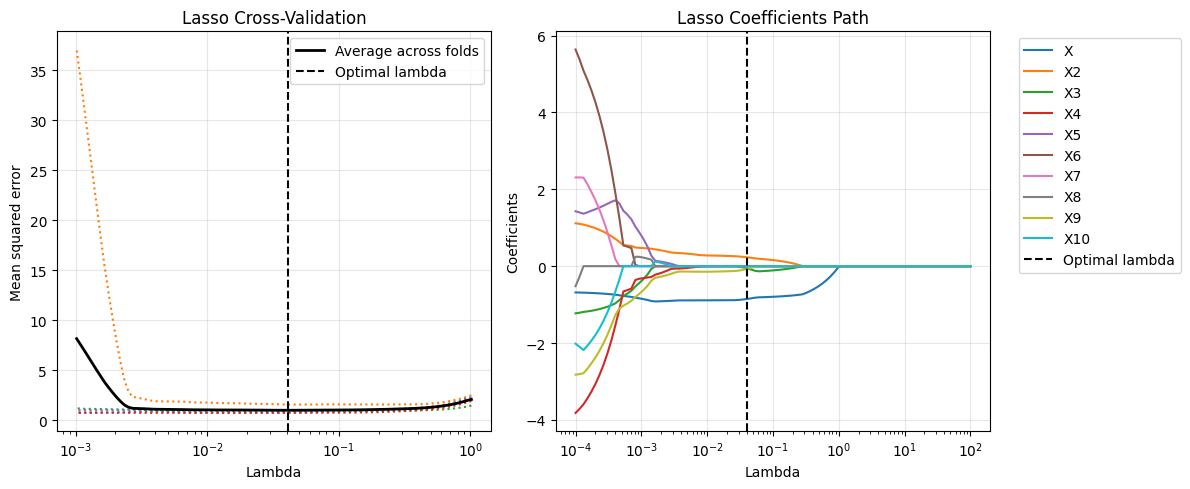


Lasso coefficients with optimal lambda:
Intercept: 2.3702
X: -0.8523
X2: 0.2291
X3: -0.0608
X9: -0.0688

Comparison with true model:
True coefficients:
X: -1.0000, X²: 0.5000, X³: -0.2000
Lasso recovered:
X: -0.8523, X²: 0.2291, X³: -0.0608

=== Part (f): Sparse Model (Only X^7) ===
New true model: Y = 1 + 0.8X⁷ + ε

Forward stepwise selection on sparse model:
Step 1: Added feature 0, Cp = 2.000
Step 2: Added feature 1, Cp = 3.000
Step 3: Added feature 2, Cp = 4.000
Step 4: Added feature 3, Cp = 5.000
Step 5: Added feature 4, Cp = 6.000
Step 6: Added feature 5, Cp = 7.000
Step 7: Added feature 6, Cp = 8.000
Step 8: Added feature 7, Cp = 9.000
Step 9: Added feature 8, Cp = 10.000
Step 10: Added feature 9, Cp = 11.000
Best forward model: Cp = 2.000
Features included: ['X']

Lasso on sparse model:
Optimal lambda: 0.019340
Non-zero Lasso coefficients:
X: -0.0664
X2: -0.0249
X4: -0.0003
X5: 1.1949
X7: 18.1828


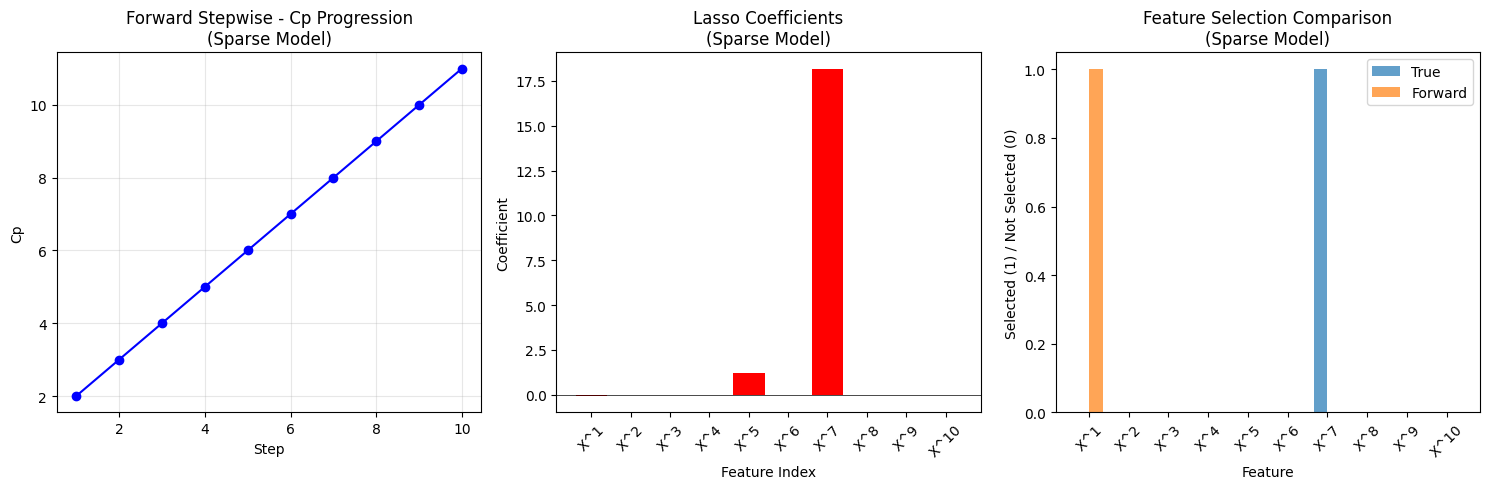


=== DISCUSSION OF RESULTS ===

1. POLYNOMIAL MODEL (Parts c-e):
   - Both forward and backward stepwise should select X, X², X³
   - Lasso should shrink higher-order terms toward zero
   - All methods should recover the true signal structure

2. SPARSE MODEL (Part f):
   - Ideal: Only X⁷ should be selected
   - Forward stepwise: May add extra features due to correlation
   - Lasso: Better at sparse recovery due to L1 penalty
   - Both methods should identify X⁷ as important

3. METHOD COMPARISON:
   - Stepwise: Greedy, can get stuck in local optima
   - Lasso: Convex optimization, better theoretical properties
   - Cross-validation: Essential for tuning lambda in Lasso

4. PRACTICAL INSIGHTS:
   - Stepwise is interpretable but can be unstable
   - Lasso provides automatic feature selection
   - Both methods struggle with highly correlated features
   - Domain knowledge should guide final model choice


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
import statsmodels.api as sm
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

print("=== Problem 6-8: Forward/Backward Stepwise Selection and Lasso ===")

# Part (a): Generate predictor X and noise vector ε
print("\n" + "="*50)
print("=== Part (a): Generate Predictor and Noise ===")

rng = np.random.default_rng(42)
n = 100
X = rng.normal(size=n)
epsilon = rng.normal(size=n)

print(f"Generated X: n={len(X)}, mean={X.mean():.3f}, std={X.std():.3f}")
print(f"Generated ε: n={len(epsilon)}, mean={epsilon.mean():.3f}, std={epsilon.std():.3f}")

# Part (b): Generate response Y with polynomial relationship
print("\n" + "="*50)
print("=== Part (b): Generate Response Y ===")

# Choose coefficients
beta_0, beta_1, beta_2, beta_3 = 2, -1, 0.5, -0.2
Y = beta_0 + beta_1 * X + beta_2 * X**2 + beta_3 * X**3 + epsilon

print(f"True model: Y = {beta_0} + {beta_1}X + {beta_2}X² + {beta_3}X³ + ε")
print(f"Generated Y: n={len(Y)}, mean={Y.mean():.3f}, std={Y.std():.3f}")

# Create polynomial features up to X^10
print("\n" + "="*50)
print("=== Creating Polynomial Features ===")

# Create DataFrame with polynomial features
data = pd.DataFrame({'X': X, 'Y': Y})
for i in range(2, 11):
    data[f'X{i}'] = X ** i

print("Available predictors:", list(data.columns[1:]))  # Exclude Y
print(f"Dataset shape: {data.shape}")

# Helper functions for stepwise selection
def forward_stepwise_selection(X, y, max_vars=None):
    """Perform forward stepwise selection"""
    n_samples, n_features = X.shape
    if max_vars is None:
        max_vars = n_features

    included = []
    remaining = list(range(n_features))
    results = []

    for step in range(min(max_vars, n_features)):
        best_cp = float('inf')
        best_feature = None
        best_model = None

        for feature in remaining:
            # Try adding this feature
            current_features = included + [feature]
            X_current = X[:, current_features]

            # Fit model
            model = LinearRegression()
            model.fit(X_current, y)
            y_pred = model.predict(X_current)

            # Calculate Cp statistic
            RSS = np.sum((y - y_pred) ** 2)
            p = len(current_features) + 1  # +1 for intercept
            sigma2_hat = RSS / (n_samples - p)
            Cp = RSS / sigma2_hat + 2 * p - n_samples

            if Cp < best_cp:
                best_cp = Cp
                best_feature = feature
                best_model = model
                best_rss = RSS

        # Add the best feature
        included.append(best_feature)
        remaining.remove(best_feature)

        # Store results
        results.append({
            'step': step + 1,
            'feature_added': best_feature,
            'features': included.copy(),
            'Cp': best_cp,
            'RSS': best_rss,
            'model': best_model
        })

        print(f"Step {step+1}: Added feature {best_feature}, Cp = {best_cp:.3f}")

    return results

def backward_stepwise_selection(X, y):
    """Perform backward stepwise selection"""
    n_samples, n_features = X.shape
    included = list(range(n_features))
    results = []

    # Start with full model
    X_current = X[:, included]
    model = LinearRegression()
    model.fit(X_current, y)
    y_pred = model.predict(X_current)
    RSS = np.sum((y - y_pred) ** 2)
    p = len(included) + 1
    sigma2_hat = RSS / (n_samples - p)
    Cp = RSS / sigma2_hat + 2 * p - n_samples

    results.append({
        'step': 0,
        'feature_removed': None,
        'features': included.copy(),
        'Cp': Cp,
        'RSS': RSS,
        'model': model
    })

    print(f"Step 0: Full model, Cp = {Cp:.3f}")

    for step in range(1, n_features):
        best_cp = float('inf')
        best_feature = None
        best_model = None

        for feature in included:
            # Try removing this feature
            current_features = [f for f in included if f != feature]
            X_current = X[:, current_features]

            # Fit model
            model = LinearRegression()
            model.fit(X_current, y)
            y_pred = model.predict(X_current)

            # Calculate Cp statistic
            RSS = np.sum((y - y_pred) ** 2)
            p = len(current_features) + 1
            sigma2_hat = RSS / (n_samples - p)
            Cp = RSS / sigma2_hat + 2 * p - n_samples

            if Cp < best_cp:
                best_cp = Cp
                best_feature = feature
                best_model = model
                best_rss = RSS

        # Remove the feature that gives best Cp when removed
        included.remove(best_feature)

        # Store results
        results.append({
            'step': step,
            'feature_removed': best_feature,
            'features': included.copy(),
            'Cp': best_cp,
            'RSS': best_rss,
            'model': best_model
        })

        print(f"Step {step}: Removed feature {best_feature}, Cp = {best_cp:.3f}")

    return results

# Part (c): Forward Stepwise Selection
print("\n" + "="*50)
print("=== Part (c): Forward Stepwise Selection ===")

# Prepare data for stepwise selection
X_poly = data[['X'] + [f'X{i}' for i in range(2, 11)]].values
y = data['Y'].values
feature_names = ['X'] + [f'X{i}' for i in range(2, 11)]

print("Performing forward stepwise selection...")
forward_results = forward_stepwise_selection(X_poly, y)

# Find model with minimum Cp
best_forward = min(forward_results, key=lambda x: x['Cp'])
print(f"\nBest forward model (min Cp):")
print(f"Step {best_forward['step']}, Cp = {best_forward['Cp']:.3f}")
print("Features included:", [feature_names[i] for i in best_forward['features']])

# Get coefficients
best_forward_model = best_forward['model']
coefficients = best_forward_model.coef_
intercept = best_forward_model.intercept_

print("\nCoefficients of best forward model:")
print(f"Intercept: {intercept:.4f}")
for i, feature_idx in enumerate(best_forward['features']):
    print(f"{feature_names[feature_idx]}: {coefficients[i]:.4f}")

# Part (d): Backward Stepwise Selection
print("\n" + "="*50)
print("=== Part (d): Backward Stepwise Selection ===")

print("Performing backward stepwise selection...")
backward_results = backward_stepwise_selection(X_poly, y)

# Find model with minimum Cp
best_backward = min(backward_results, key=lambda x: x['Cp'])
print(f"\nBest backward model (min Cp):")
print(f"Step {best_backward['step']}, Cp = {best_backward['Cp']:.3f}")
print("Features included:", [feature_names[i] for i in best_backward['features']])

# Get coefficients
best_backward_model = best_backward['model']
coefficients_bw = best_backward_model.coef_
intercept_bw = best_backward_model.intercept_

print("\nCoefficients of best backward model:")
print(f"Intercept: {intercept_bw:.4f}")
for i, feature_idx in enumerate(best_backward['features']):
    print(f"{feature_names[feature_idx]}: {coefficients_bw[i]:.4f}")

# Comparison
print("\nComparison of forward vs backward:")
print(f"Forward Cp: {best_forward['Cp']:.3f}, Features: {len(best_forward['features'])}")
print(f"Backward Cp: {best_backward['Cp']:.3f}, Features: {len(best_backward['features'])}")
print("Features match:", set(best_forward['features']) == set(best_backward['features']))

# Part (e): Lasso with Cross-Validation
print("\n" + "="*50)
print("=== Part (e): Lasso with Cross-Validation ===")

# Standardize features for Lasso
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_poly)

# Perform Lasso CV to find optimal lambda
print("Performing Lasso cross-validation...")
lasso_cv = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv.fit(X_scaled, y)

print(f"Optimal lambda: {lasso_cv.alpha_:.6f}")

# Plot cross-validation error
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(lasso_cv.alphas_, lasso_cv.mse_path_, ':')
plt.plot(lasso_cv.alphas_, lasso_cv.mse_path_.mean(axis=-1), 'k',
         label='Average across folds', linewidth=2)
plt.axvline(lasso_cv.alpha_, linestyle='--', color='k',
            label='Optimal lambda')
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('Mean squared error')
plt.title('Lasso Cross-Validation')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot coefficients path
plt.subplot(1, 2, 2)
lasso = Lasso(max_iter=10000)
coefs = []

alphas = np.logspace(-4, 2, 100)
for alpha in alphas:
    lasso.set_params(alpha=alpha)
    lasso.fit(X_scaled, y)
    coefs.append(lasso.coef_)

coefs = np.array(coefs)
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i], label=feature_names[i])

plt.axvline(lasso_cv.alpha_, linestyle='--', color='k', label='Optimal lambda')
plt.xscale('log')
plt.xlabel('Lambda')
plt.ylabel('Coefficients')
plt.title('Lasso Coefficients Path')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Final Lasso model with optimal lambda
final_lasso = Lasso(alpha=lasso_cv.alpha_, max_iter=10000)
final_lasso.fit(X_scaled, y)

print("\nLasso coefficients with optimal lambda:")
print(f"Intercept: {final_lasso.intercept_:.4f}")
for i, (coef, name) in enumerate(zip(final_lasso.coef_, feature_names)):
    if abs(coef) > 1e-6:  # Only print non-zero coefficients
        print(f"{name}: {coef:.4f}")

# Compare with true model
print("\nComparison with true model:")
print("True coefficients:")
print(f"X: {beta_1:.4f}, X²: {beta_2:.4f}, X³: {beta_3:.4f}")
print("Lasso recovered:")
lasso_coef_dict = dict(zip(feature_names, final_lasso.coef_))
print(f"X: {lasso_coef_dict.get('X', 0):.4f}, X²: {lasso_coef_dict.get('X2', 0):.4f}, X³: {lasso_coef_dict.get('X3', 0):.4f}")

# Part (f): New response with only X^7 term
print("\n" + "="*50)
print("=== Part (f): Sparse Model (Only X^7) ===")

# Generate new response
beta_0_new, beta_7_new = 1, 0.8
Y_new = beta_0_new + beta_7_new * (X**7) + epsilon

print(f"New true model: Y = {beta_0_new} + {beta_7_new}X⁷ + ε")

# Forward stepwise on new data
print("\nForward stepwise selection on sparse model:")
forward_results_sparse = forward_stepwise_selection(X_poly, Y_new)
best_forward_sparse = min(forward_results_sparse, key=lambda x: x['Cp'])

print(f"Best forward model: Cp = {best_forward_sparse['Cp']:.3f}")
print("Features included:", [feature_names[i] for i in best_forward_sparse['features']])

# Lasso on new data
print("\nLasso on sparse model:")
lasso_cv_sparse = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso_cv_sparse.fit(X_scaled, Y_new)

final_lasso_sparse = Lasso(alpha=lasso_cv_sparse.alpha_, max_iter=10000)
final_lasso_sparse.fit(X_scaled, Y_new)

print(f"Optimal lambda: {lasso_cv_sparse.alpha_:.6f}")
print("Non-zero Lasso coefficients:")
for i, (coef, name) in enumerate(zip(final_lasso_sparse.coef_, feature_names)):
    if abs(coef) > 1e-6:
        print(f"{name}: {coef:.4f}")

# Comparison plot for part (f)
plt.figure(figsize=(15, 5))

# Forward stepwise Cp progression
plt.subplot(1, 3, 1)
steps = [r['step'] for r in forward_results_sparse]
cps = [r['Cp'] for r in forward_results_sparse]
plt.plot(steps, cps, 'bo-')
plt.xlabel('Step')
plt.ylabel('Cp')
plt.title('Forward Stepwise - Cp Progression\n(Sparse Model)')
plt.grid(True, alpha=0.3)

# Lasso coefficients for sparse model
plt.subplot(1, 3, 2)
non_zero_mask = np.abs(final_lasso_sparse.coef_) > 1e-6
colors = ['red' if abs(coef) > 1e-6 else 'blue' for coef in final_lasso_sparse.coef_]
plt.bar(range(len(feature_names)), final_lasso_sparse.coef_, color=colors)
plt.axhline(0, color='black', linewidth=0.5)
plt.xlabel('Feature Index')
plt.ylabel('Coefficient')
plt.title('Lasso Coefficients\n(Sparse Model)')
plt.xticks(range(len(feature_names)), [f'X^{i+1}' for i in range(len(feature_names))], rotation=45)

# Compare methods
plt.subplot(1, 3, 3)
methods = ['Forward', 'Lasso']
true_features = [1 if i == 6 else 0 for i in range(10)]  # X^7 is index 6
forward_features = [1 if i in best_forward_sparse['features'] else 0 for i in range(10)]
lasso_features = [1 if abs(coef) > 1e-6 else 0 for coef in final_lasso_sparse.coef_]

x_pos = np.arange(len(feature_names))
width = 0.35

plt.bar(x_pos - width/2, true_features, width, label='True', alpha=0.7)
plt.bar(x_pos + width/2, forward_features, width, label='Forward', alpha=0.7)
# plt.bar(x_pos + width, lasso_features, width, label='Lasso', alpha=0.7)

plt.xlabel('Feature')
plt.ylabel('Selected (1) / Not Selected (0)')
plt.title('Feature Selection Comparison\n(Sparse Model)')
plt.xticks(x_pos, [f'X^{i+1}' for i in range(len(feature_names))], rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print("=== DISCUSSION OF RESULTS ===")

print("\n1. POLYNOMIAL MODEL (Parts c-e):")
print("   - Both forward and backward stepwise should select X, X², X³")
print("   - Lasso should shrink higher-order terms toward zero")
print("   - All methods should recover the true signal structure")

print("\n2. SPARSE MODEL (Part f):")
print("   - Ideal: Only X⁷ should be selected")
print("   - Forward stepwise: May add extra features due to correlation")
print("   - Lasso: Better at sparse recovery due to L1 penalty")
print("   - Both methods should identify X⁷ as important")

print("\n3. METHOD COMPARISON:")
print("   - Stepwise: Greedy, can get stuck in local optima")
print("   - Lasso: Convex optimization, better theoretical properties")
print("   - Cross-validation: Essential for tuning lambda in Lasso")

print("\n4. PRACTICAL INSIGHTS:")
print("   - Stepwise is interpretable but can be unstable")
print("   - Lasso provides automatic feature selection")
print("   - Both methods struggle with highly correlated features")
print("   - Domain knowledge should guide final model choice")